In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
%matplotlib inline


In [3]:
df=pd.read_csv('dataset.csv')

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df['EmployeeNumber'].value_counts()

EmployeeNumber
1       1
1391    1
1389    1
1387    1
1383    1
       ..
659     1
657     1
656     1
655     1
2068    1
Name: count, Length: 1470, dtype: int64

In [7]:
df['BusinessTravel'].value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

In [8]:
df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [9]:
df['EducationField'].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [35]:
df['JobRole'].value_counts()

 37  JobRole_Human Resources            2466 non-null   int64 
 30  JobRole_Laboratory Technician      2466 non-null   int64 
 31  JobRole_Manager                    2466 non-null   int64 
 32  JobRole_Manufacturing Director     2466 non-null   int64 
 33  JobRole_Research Director          2466 non-null   int64 
 34  JobRole_Research Scientist         2466 non-null   int64 
 35  JobRole_Sales Executive            2466 non-null   int64 
 36  JobRole_Sales Representative 

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [11]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

In [12]:
df['Over18'].value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [13]:
df['OverTime'].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

Columns where we apply OneHotEncoder

1. BusinessTravel
2. Department
3. EducationField
4. JobRole


Columns where we apply LabelEncoder

1. OverTime
2. Gender

In [14]:
df.drop(['Over18'],axis=1,inplace=True)

In [15]:
# Chi-square for categorical column #

In [16]:
df1=df[['BusinessTravel','Department','EducationField','JobRole','Attrition','MaritalStatus','Gender','OverTime']]

In [17]:
df1.head()

,BusinessTravel,Department,EducationField,JobRole,Attrition,MaritalStatus,Gender,OverTime
0,Travel_Rarely,Sales,Life Sciences,Sales Executive,Yes,Single,Female,Yes
1,Travel_Frequently,Research & Development,Life Sciences,Research Scientist,No,Married,Male,No
2,Travel_Rarely,Research & Development,Other,Laboratory Technician,Yes,Single,Male,Yes
3,Travel_Frequently,Research & Development,Life Sciences,Research Scientist,No,Married,Female,Yes
4,Travel_Rarely,Research & Development,Medical,Laboratory Technician,No,Married,Male,No


In [18]:
for col in df1.columns:
    le=LabelEncoder()
    df1[col]=le.fit_transform(df1[col])
df1.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19776\2023613383.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col]=le.fit_transform(df1[col])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_19776\2023613383.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[col]=le.fit_transform(df1[col])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_19776\2023613383.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

,BusinessTravel,Department,EducationField,JobRole,Attrition,MaritalStatus,Gender,OverTime
0,2,2,1,7,1,2,0,1
1,1,1,1,6,0,1,1,0
2,2,1,4,2,1,2,1,1
3,1,1,1,6,0,1,0,1
4,2,1,3,2,0,1,1,0


In [19]:
x=df1.drop(columns=['Attrition'],axis=1)
y=df1['Attrition']

In [20]:
chi_scores=chi2(x,y)
chi_scores

(array([2.20269350e-06, 1.32929732e+00, 8.34911631e-01, 9.00444847e+00,
        1.87456575e+01, 5.10086544e-01, 6.38450667e+01]),
 array([9.98815822e-01, 2.48930264e-01, 3.60856114e-01, 2.69323253e-03,
        1.49363092e-05, 4.75101394e-01, 1.34598985e-15]))

<Axes: >

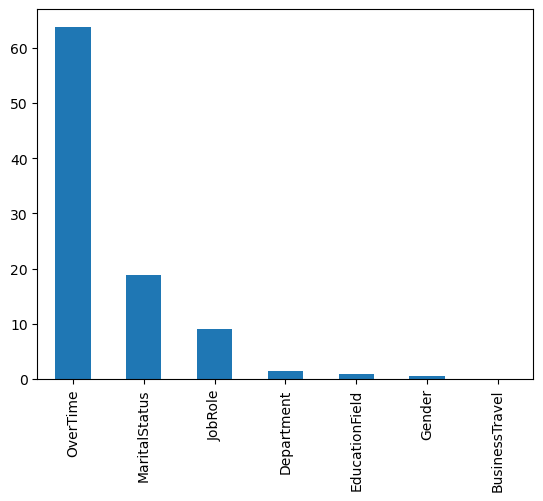

In [21]:
chi_values=pd.Series(chi_scores[0],index=x.columns)
chi_values.sort_values(ascending=False,inplace=True)
chi_values.plot.bar()

In [22]:
chi_scores[1]

array([9.98815822e-01, 2.48930264e-01, 3.60856114e-01, 2.69323253e-03,
       1.49363092e-05, 4.75101394e-01, 1.34598985e-15])

In [54]:
df['Attrition']

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int32

<Axes: >

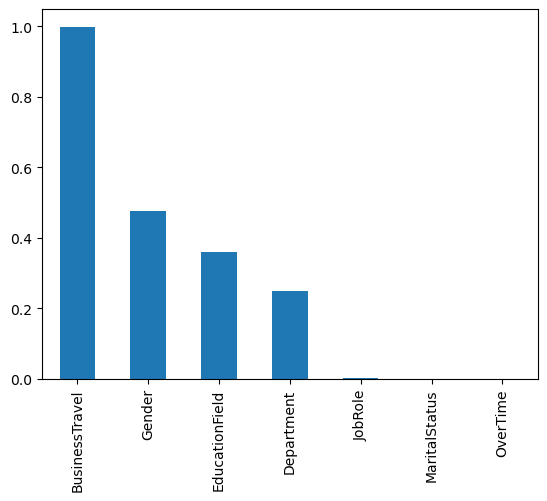

In [23]:
# if p-value > 0.05, lower the importance
chi_values=pd.Series(chi_scores[1],index=x.columns)
chi_values.sort_values(ascending=False,inplace=True)
chi_values.plot.bar()

From the above two graphs we can say that MartialStatus , OverTime Jobrole are most important while department and Education Field do have an impact while gender and BusinessTravel and Gender don't have any importance.

In [24]:
df['Attrition']=le.fit_transform(df['Attrition'])

In [53]:
importances[indices], feature_names[indices]

(array([0.08184798, 0.07033684, 0.0675383 , 0.06369475, 0.0591894 ,
        0.05705325, 0.05632322, 0.05523542, 0.04381972, 0.04248684,
        0.04119243, 0.03711992, 0.03611988, 0.03557251, 0.03132711,
        0.03082962, 0.03059374, 0.03042976, 0.02712005, 0.02658825,
        0.02551436, 0.02382582, 0.02148719, 0.00475364, 0.        ,
        0.        ]),
 Index(['MonthlyIncome', 'Age', 'DailyRate', 'EmployeeNumber', 'MonthlyRate',
        'HourlyRate', 'TotalWorkingYears', 'DistanceFromHome',
        'NumCompaniesWorked', 'YearsAtCompany', 'PercentSalaryHike',
        'StockOptionLevel', 'YearsWithCurrManager', 'EnvironmentSatisfaction',
        'JobInvolvement', 'JobSatisfaction', 'YearsSinceLastPromotion',
        'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsInCurrentRole',
        'RelationshipSatisfaction', 'Education', 'JobLevel',
        'PerformanceRating', 'EmployeeCount', 'StandardHours'],
       dtype='object'))

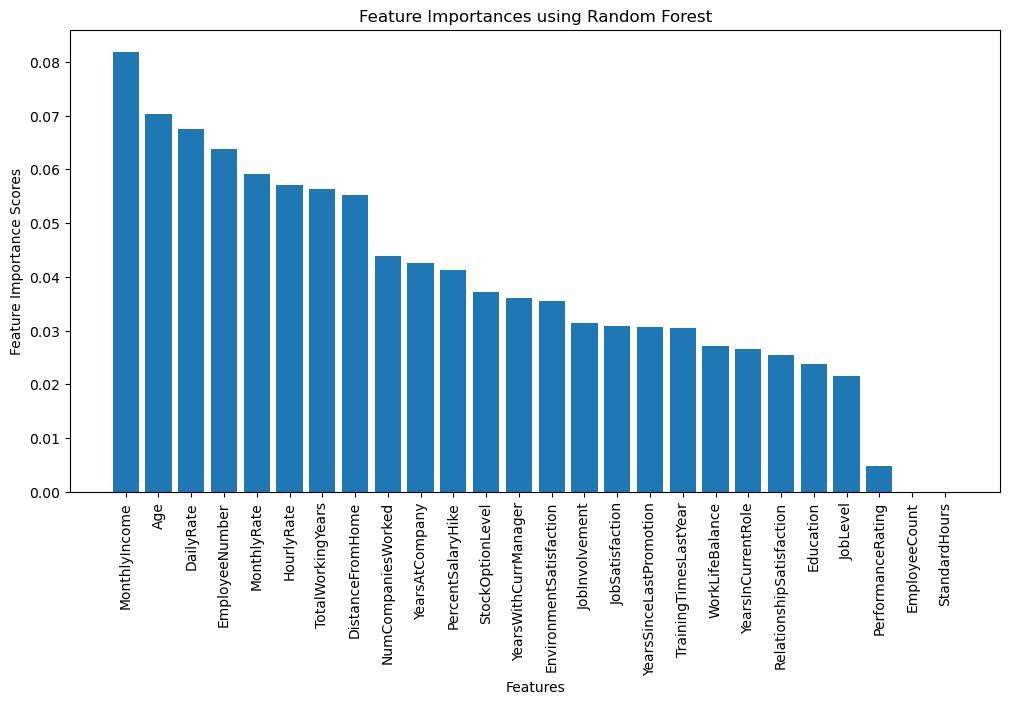

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
selected_features = df.drop(['BusinessTravel', 'Department', 'EducationField', 'JobRole', 
                             'Attrition', 'MaritalStatus','Gender','OverTime'], axis=1)

rf_model.fit(selected_features, df['Attrition'])
importances = rf_model.feature_importances_

feature_names = selected_features.columns
indices = np.argsort(importances)[::-1]  # Sort in descending order

plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_names)), importances[indices], align="center")
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=90)
plt.ylabel('Feature Importance Scores')
plt.xlabel('Features')
plt.title('Feature Importances using Random Forest')
plt.show()


In [26]:
df2=df.drop(['BusinessTravel','Department','EducationField','JobRole','MaritalStatus','Gender','OverTime'],axis=1)
anova_values=[]


for i in df2.columns:
    groups = [df2[df2['Attrition'] == category][i] for category in df2['Attrition'].unique()]
    stat, p = f_oneway(*groups)
    anova_values.append(p)
    print(f"column:{i} F-statistic: {stat}, P-value: {p}")
    

print(anova_values)


column:Age F-statistic: 38.175886789733404, P-value: 8.356308021102401e-10
column:Attrition F-statistic: inf, P-value: 0.0
column:DailyRate F-statistic: 4.726639837649272, P-value: 0.02985816066026101
column:DistanceFromHome F-statistic: 8.968276593814723, P-value: 0.0027930600802132115
column:Education F-statistic: 1.4463081305523098, P-value: 0.2293152033222874
column:EmployeeCount F-statistic: nan, P-value: nan
column:EmployeeNumber F-statistic: 0.1642553750949558, P-value: 0.685327589729904
column:EnvironmentSatisfaction F-statistic: 15.855209080957504, P-value: 7.172338549367721e-05
column:HourlyRate F-statistic: 0.06879597773678614, P-value: 0.7931347689944519
column:JobInvolvement F-statistic: 25.241985036473384, P-value: 5.677065356744583e-07
column:JobLevel F-statistic: 43.215343827677955, P-value: 6.795384780014228e-11
column:JobSatisfaction F-statistic: 15.890003806510506, P-value: 7.043066741730351e-05
column:MonthlyIncome F-statistic: 38.488818983801764, P-value: 7.1473639

C:\ProgramData\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


<Axes: >

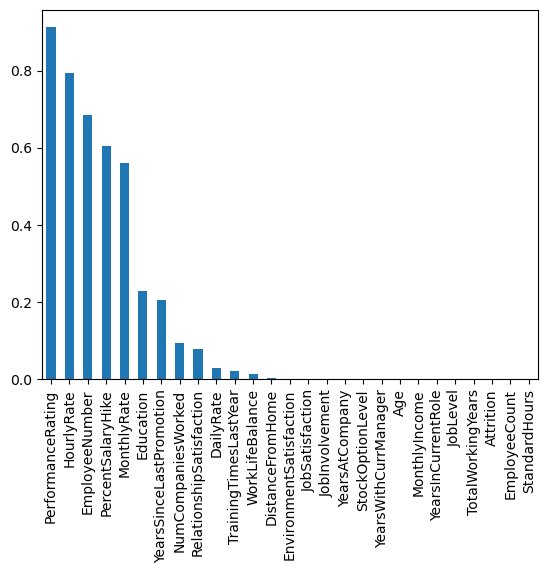

In [27]:
anova_values=pd.Series(anova_values,index=df2.columns)
anova_values.sort_values(ascending=False,inplace=True)
anova_values.plot.bar()

From the above Graphs we can say that PerformanceRating,HourlyRate,PercentSalaryHike are not important for model training

In [28]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int32 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [30]:
df_model=df.drop(['BusinessTravel','PerformanceRating','HourlyRate','PercentSalaryHike'],axis=1)

In [31]:
df_model.head()

,Age,Attrition,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,0,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,1,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,0,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [32]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int32 
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [33]:
#One-hot Encoder - Department, EducationField , JobRole , MaritalStatus , Gender
df_encoded=pd.get_dummies(df_model,columns=['Department', 'EducationField' , 'JobRole' , 'MaritalStatus' , 'Gender','OverTime'],drop_first=True)
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
0,41,1,1102,1,2,1,1,2,3,2,...,False,False,False,False,True,False,False,True,False,True
1,49,0,279,8,1,1,2,3,2,2,...,False,False,False,True,False,False,True,False,True,False
2,37,1,1373,2,2,1,4,4,2,1,...,False,False,False,False,False,False,False,True,True,True
3,33,0,1392,3,4,1,5,4,3,1,...,False,False,False,True,False,False,True,False,False,True
4,27,0,591,2,1,1,7,1,3,1,...,False,False,False,False,False,False,True,False,True,False


In [34]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int32
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EmployeeCount                      1470 non-null   int64
 6   EmployeeNumber                     1470 non-null   int64
 7   EnvironmentSatisfaction            1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate         

In [35]:
df_encoded.dtypes['Gender_Male']=='bool'

True

In [36]:
for i in df_encoded.columns:
    if df_encoded.dtypes[i]=='bool':
        df_encoded[i]=df_encoded[i].apply(lambda x:1 if x==True else 0)

In [55]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int32
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   EnvironmentSatisfaction            1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [37]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
0,41,1,1102,1,2,1,1,2,3,2,...,0,0,0,0,1,0,0,1,0,1
1,49,0,279,8,1,1,2,3,2,2,...,0,0,0,1,0,0,1,0,1,0
2,37,1,1373,2,2,1,4,4,2,1,...,0,0,0,0,0,0,0,1,1,1
3,33,0,1392,3,4,1,5,4,3,1,...,0,0,0,1,0,0,1,0,0,1
4,27,0,591,2,1,1,7,1,3,1,...,0,0,0,0,0,0,1,0,1,0


In [38]:
df_encoded.drop(['EmployeeCount'],axis=1,inplace=True)

In [39]:
df_encoded['JobInvolvement'].value_counts()

JobInvolvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64

In [78]:
x_train, x_test, y_train, y_test = train_test_split(df_encoded.drop('Attrition',axis=1), df_encoded['Attrition'], 
                                                    test_size=0.3, random_state=42,stratify=y)

# Initialize the SGDClassifier with logistic regression loss
sgd_clf = SGDClassifier(loss="log", max_iter=1000, tol=1e-3, random_state=42)

# Train the classifier
sgd_clf.fit(x_train, y_train)

# Make predictions
y_pred = sgd_clf.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(sgd_clf.score(x_train,y_train))
print(sgd_clf.score(x_test,y_test))

Accuracy: 0.8390
0.8377065111758989
0.8390022675736961


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


In [85]:
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(log_reg.score(x_train,y_train))
print(f"Accuracy: {accuracy:.4f}")

0.8445092322643343
Accuracy: 0.8458


C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [137]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int32
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   EnvironmentSatisfaction            1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [40]:
# Step 1: Separate rows where all EducationField columns are zero
# Assuming columns related to 'EducationField' are one-hot encoded as shown in your data
X,y = df_encoded.drop('Attrition',axis=1), df_encoded['Attrition']

education_fields = ['EducationField_Life Sciences', 'EducationField_Marketing', 
                    'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree']
department_fields=['Department_Research & Development','Department_Sales']
Job_role_fields=['JobRole_Human Resources','JobRole_Laboratory Technician','JobRole_Manager','JobRole_Manufacturing Director',
                'JobRole_Research Director','JobRole_Research Scientist','JobRole_Sales Executive','JobRole_Sales Representative']
martialstatus_fields=['MaritalStatus_Married','MaritalStatus_Single']

zero_education_field_rows = X[(X[education_fields] == 0).all(axis=1)]
zero_department_field_rows = X[(X[department_fields] == 0).all(axis=1)]
zero_jobrole_field_rows = X[(X[Job_role_fields] == 0).all(axis=1)]
zero_martialstatus_field_rows = X[(X[martialstatus_fields] == 0).all(axis=1)]




# Step 2: Separate rows where other columns might be zero, if needed
# Example for another column, say 'Gender' (if it's one-hot encoded)
# zero_gender_rows = X[(X[['Gender_Male', 'Gender_Female']] == 0).all(axis=1)]

rows_to_drop = zero_education_field_rows.index.union(zero_department_field_rows.index) \
                           .union(zero_jobrole_field_rows.index) \
                           .union(zero_martialstatus_field_rows.index)

# Step 3: Remove these rows from the dataset
X_without_zero_fields = X.drop(rows_to_drop)  # Removing zero education fields rows
y_without_zero_fields = y.drop(rows_to_drop)  # Corresponding labels

# Step 4: Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_without_zero_fields, y_without_zero_fields)

# Step 5: Reattach the separated zero-education-field rows back into the dataset
X_final = pd.concat([X_resampled, zero_education_field_rows])
y_final = pd.concat([y_resampled, y[zero_education_field_rows.index]])

# Shuffle the final dataset to randomize the order of rows
final_data = X_final.sample(frac=1, random_state=42).reset_index(drop=True)
final_labels = y_final.sample(frac=1, random_state=42).reset_index(drop=True)

# Now proceed with training your machine learning model


In [242]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1647 entries, 0 to 1646
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1647 non-null   int64 
 1   DailyRate                 1647 non-null   int64 
 2   DistanceFromHome          1647 non-null   int64 
 3   Education                 1647 non-null   int64 
 4   EmployeeNumber            1647 non-null   int64 
 5   EnvironmentSatisfaction   1647 non-null   int64 
 6   JobInvolvement            1647 non-null   int64 
 7   JobLevel                  1647 non-null   int64 
 8   JobSatisfaction           1647 non-null   int64 
 9   MonthlyIncome             1647 non-null   int64 
 10  MonthlyRate               1647 non-null   int64 
 11  NumCompaniesWorked        1647 non-null   int64 
 12  RelationshipSatisfaction  1647 non-null   int64 
 13  StandardHours             1647 non-null   int64 
 14  StockOptionLevel        

In [243]:
final_data.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Gender', 'OverTime', 'EducationField',
       'DepartmentField', 'JobRoleField', 'MaritalStatus'],
      dtype='object')

In [45]:
final_data.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
0,27,135,17,4,1405,4,3,1,3,2394,...,0,0,0,1,0,0,0,1,0,1
1,47,802,3,2,96,1,1,1,2,2614,...,0,0,0,0,0,0,1,0,1,1
2,24,381,9,3,1494,2,3,1,1,3172,...,0,0,0,0,0,0,0,1,1,1
3,46,366,3,2,591,2,2,2,3,5533,...,0,0,0,0,1,0,0,0,1,0
4,29,925,2,3,777,3,3,1,3,4494,...,0,0,0,0,0,0,0,0,0,0


In [41]:
#smote = SMOTE(sampling_strategy=1, random_state=42)  # Adjust ratio as needed
#X,y = smote.fit_resample(df_encoded.drop('Attrition',axis=1), df_encoded['Attrition'])
x_train, x_test, y_train, y_test = train_test_split(final_data,final_labels,test_size=0.3, random_state=42)


pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

pipe2.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [42]:
x_train.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
522,28,421,22,3,1528,3,3,1,2,2442,...,0,0,0,0,0,0,1,0,1,0
1304,31,979,1,4,308,3,1,2,3,4345,...,0,1,0,0,0,0,1,0,1,0
31,49,1313,11,4,1757,4,3,2,4,4507,...,0,0,0,0,1,0,0,1,0,0
1033,26,578,3,1,507,3,2,1,1,3103,...,0,0,0,0,0,0,0,1,1,0
210,44,602,1,5,1642,1,3,2,4,5743,...,0,0,0,0,0,0,1,0,1,1


In [44]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1152 entries, 522 to 1126
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1152 non-null   int64
 1   DailyRate                          1152 non-null   int64
 2   DistanceFromHome                   1152 non-null   int64
 3   Education                          1152 non-null   int64
 4   EmployeeNumber                     1152 non-null   int64
 5   EnvironmentSatisfaction            1152 non-null   int64
 6   JobInvolvement                     1152 non-null   int64
 7   JobLevel                           1152 non-null   int64
 8   JobSatisfaction                    1152 non-null   int64
 9   MonthlyIncome                      1152 non-null   int64
 10  MonthlyRate                        1152 non-null   int64
 11  NumCompaniesWorked                 1152 non-null   int64
 12  RelationshipSatisfactio

In [46]:
pipe2.predict(x_test)

array([1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,

In [43]:
y_pred=pipe2.predict(x_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       248
           1       0.90      0.87      0.89       247

    accuracy                           0.89       495
   macro avg       0.89      0.89      0.89       495
weighted avg       0.89      0.89      0.89       495



In [48]:
x_test.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
680,34,520,6,3,1670,4,3,1,1,2022,...,0,0,0,0,0,0,0,0,1,0
1412,30,1398,22,4,567,3,3,3,1,8412,...,0,0,0,0,1,0,1,0,0,0
724,27,274,28,2,1064,2,1,1,1,4861,...,0,0,0,0,0,0,0,1,1,0
1358,31,384,4,2,484,3,2,1,2,2793,...,0,0,0,0,0,1,0,1,0,1
1274,30,138,22,3,1004,1,3,1,3,2132,...,0,0,0,1,0,0,1,0,0,1


In [57]:
predicted_probs = pipe2.predict_proba(x_test)[:, 1]
predicted_probs

array([9.99967562e-01, 1.19457135e-01, 9.93242902e-01, 9.98535800e-01,
       6.51677231e-01, 1.15823794e-02, 1.34188796e-01, 1.61571708e-01,
       8.88307404e-01, 1.53353204e-01, 3.47513265e-02, 6.84474129e-02,
       5.37316591e-02, 3.32228068e-01, 9.80248379e-01, 7.09992344e-01,
       6.42390704e-02, 3.84353075e-01, 6.21053315e-02, 9.92904450e-02,
       9.99865454e-01, 6.36794787e-02, 9.99876639e-01, 9.22769331e-01,
       9.99702576e-01, 3.92570525e-01, 1.69756893e-01, 9.42225436e-02,
       3.07827230e-01, 9.99982388e-01, 3.07143352e-02, 3.74828657e-01,
       9.99991881e-01, 9.90125222e-01, 9.99175830e-01, 9.99997614e-01,
       1.99825256e-02, 9.99993288e-01, 1.03977897e-01, 9.99954322e-01,
       9.90987724e-01, 9.99566089e-01, 1.99376073e-01, 2.07989752e-02,
       3.26850670e-01, 9.99569217e-01, 6.38035060e-02, 9.99530704e-01,
       9.95472239e-01, 2.13546374e-01, 1.83820417e-01, 9.99546956e-01,
       9.99783677e-01, 9.99991074e-01, 6.65287087e-02, 2.67041149e-02,
      

In [67]:

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

# Train the classifier
rf_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(rf_model.score(x_train,y_train))
print(f"Accuracy: {accuracy:.4f}")

1.0
Accuracy: 0.8753


In [68]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the model
svm_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(x_test)

# Evaluate the model
print(svm_model.score(x_train,y_train))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

0.8289601554907677
Accuracy: 0.8617


In [69]:
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(x_train, y_train)

# Make predictions
y_pred = knn.predict(x_test)

# Evaluate the model
print(knn.score(x_train,y_train))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

0.8833819241982507
Accuracy: 0.8095


In [113]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
0,41,1102,1,2,1,2,3,2,4,5993,...,0,0,0,0,1,0,0,1,0,1
1,49,279,8,1,2,3,2,2,2,5130,...,0,0,0,1,0,0,1,0,1,0
2,37,1373,2,2,4,4,2,1,3,2090,...,0,0,0,0,0,0,0,1,1,1
3,33,1392,3,4,5,4,3,1,3,2909,...,0,0,0,1,0,0,1,0,0,1
4,27,591,2,1,7,1,3,1,2,3468,...,0,0,0,0,0,0,1,0,1,0


In [118]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                2466 non-null   int64 
 1   DailyRate                          2466 non-null   int64 
 2   DistanceFromHome                   2466 non-null   int64 
 3   Education                          2466 non-null   int64 
 4   EmployeeNumber                     2466 non-null   int64 
 5   EnvironmentSatisfaction            2466 non-null   int64 
 6   JobInvolvement                     2466 non-null   int64 
 7   JobLevel                           2466 non-null   int64 
 8   JobSatisfaction                    2466 non-null   int64 
 9   MonthlyIncome                      2466 non-null   int64 
 10  MonthlyRate                        2466 non-null   int64 
 11  NumCompaniesWorked                 2466 non-null   int64 
 12  Relati

# Making original dataset for power BI

In [207]:
final_data['EducationField']=''

In [208]:
final_data['DepartmentField']=''

In [209]:
final_data['JobRoleField']=''

In [210]:
final_data['MaritalStatus']=''

In [211]:
df['EducationField'].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [212]:
import numpy as np

edu_cols = [
    "EducationField_Life Sciences",
    "EducationField_Marketing",
    "EducationField_Medical",
    "EducationField_Other",
    "EducationField_Technical Degree"
]
dept_cols=[
    'Department_Research & Development',
    'Department_Sales'
]
jobrole_cols=[
    'JobRole_Human Resources',
    'JobRole_Laboratory Technician',
    'JobRole_Manager',
    'JobRole_Manufacturing Director',
    'JobRole_Research Director',
    'JobRole_Research Scientist',
    'JobRole_Sales Executive',
    'JobRole_Sales Representative'
]
martial_cols=[
    'MaritalStatus_Married',
    'MaritalStatus_Single'
]

final_data["EducationField"] = final_data[edu_cols].idxmax(axis=1)
final_data["DepartmentField"] = final_data[dept_cols].idxmax(axis=1)
final_data["JobRoleField"] = final_data[jobrole_cols].idxmax(axis=1)
final_data["MaritalStatus"] = final_data[martial_cols].idxmax(axis=1)



final_data["EducationField"] = final_data["EducationField"].str.replace("EducationField_", "", regex=False)
final_data["DepartmentField"] = final_data["DepartmentField"].str.replace("Department_", "", regex=False)
final_data["JobRoleField"] = final_data["JobRoleField"].str.replace("JobRole_", "", regex=False)
final_data["MaritalStatus"] = final_data["MaritalStatus"].str.replace("MaritalStatus_", "", regex=False)


no_category_rows1 = (final_data[edu_cols].sum(axis=1) == 0)
no_category_rows2 = (final_data[dept_cols].sum(axis=1) == 0)
no_category_rows3 = (final_data[jobrole_cols].sum(axis=1) == 0)
no_category_rows4 = (final_data[martial_cols].sum(axis=1) == 0)


final_data.loc[no_category_rows1, "EducationField"] = "Human Resources"
final_data.loc[no_category_rows2, "DepartmentField"] = "Human Resources"
final_data.loc[no_category_rows3, "JobRoleField"] = "Healthcare Representative"
final_data.loc[no_category_rows4, "MaritalStatus"] = "Divorced"



print(final_data["EducationField"].value_counts())
print(final_data["DepartmentField"].value_counts())
print(final_data["JobRoleField"].value_counts())
print(final_data["MaritalStatus"].value_counts())

EducationField
Life Sciences       534
Human Resources     488
Medical             333
Marketing           143
Technical Degree     95
Other                54
Name: count, dtype: int64
DepartmentField
Research & Development    861
Sales                     497
Human Resources           289
Name: count, dtype: int64
JobRoleField
Healthcare Representative    378
Sales Executive              364
Research Scientist           282
Laboratory Technician        256
Manufacturing Director       112
Sales Representative          99
Manager                       78
Research Director             57
Human Resources               21
Name: count, dtype: int64
MaritalStatus
Married     691
Single      664
Divorced    292
Name: count, dtype: int64


In [164]:
x_train.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
522,28,421,22,3,1528,3,3,1,2,2442,...,0,0,0,0,0,0,1,0,1,0
1304,31,979,1,4,308,3,1,2,3,4345,...,0,1,0,0,0,0,1,0,1,0
31,49,1313,11,4,1757,4,3,2,4,4507,...,0,0,0,0,1,0,0,1,0,0
1033,26,578,3,1,507,3,2,1,1,3103,...,0,0,0,0,0,0,0,1,1,0
210,44,602,1,5,1642,1,3,2,4,5743,...,0,0,0,0,0,0,1,0,1,1


In [49]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1152 entries, 522 to 1126
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1152 non-null   int64
 1   DailyRate                          1152 non-null   int64
 2   DistanceFromHome                   1152 non-null   int64
 3   Education                          1152 non-null   int64
 4   EmployeeNumber                     1152 non-null   int64
 5   EnvironmentSatisfaction            1152 non-null   int64
 6   JobInvolvement                     1152 non-null   int64
 7   JobLevel                           1152 non-null   int64
 8   JobSatisfaction                    1152 non-null   int64
 9   MonthlyIncome                      1152 non-null   int64
 10  MonthlyRate                        1152 non-null   int64
 11  NumCompaniesWorked                 1152 non-null   int64
 12  RelationshipSatisfactio

In [165]:
pipe2.predict_proba(x_test)

array([[3.24376988e-05, 9.99967562e-01],
       [8.80542865e-01, 1.19457135e-01],
       [6.75709844e-03, 9.93242902e-01],
       [1.46419991e-03, 9.98535800e-01],
       [3.48322769e-01, 6.51677231e-01],
       [9.88417621e-01, 1.15823794e-02],
       [8.65811204e-01, 1.34188796e-01],
       [8.38428292e-01, 1.61571708e-01],
       [1.11692596e-01, 8.88307404e-01],
       [8.46646796e-01, 1.53353204e-01],
       [9.65248673e-01, 3.47513265e-02],
       [9.31552587e-01, 6.84474129e-02],
       [9.46268341e-01, 5.37316591e-02],
       [6.67771932e-01, 3.32228068e-01],
       [1.97516206e-02, 9.80248379e-01],
       [2.90007656e-01, 7.09992344e-01],
       [9.35760930e-01, 6.42390704e-02],
       [6.15646925e-01, 3.84353075e-01],
       [9.37894669e-01, 6.21053315e-02],
       [9.00709555e-01, 9.92904450e-02],
       [1.34545600e-04, 9.99865454e-01],
       [9.36320521e-01, 6.36794787e-02],
       [1.23361481e-04, 9.99876639e-01],
       [7.72306685e-02, 9.22769331e-01],
       [2.974241

In [213]:
df_model=pd.concat([x_train,x_test])

In [214]:
df_model.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes
522,28,421,22,3,1528,3,3,1,2,2442,...,0,0,0,0,0,0,1,0,1,0
1304,31,979,1,4,308,3,1,2,3,4345,...,0,1,0,0,0,0,1,0,1,0
31,49,1313,11,4,1757,4,3,2,4,4507,...,0,0,0,0,1,0,0,1,0,0
1033,26,578,3,1,507,3,2,1,1,3103,...,0,0,0,0,0,0,0,1,1,0
210,44,602,1,5,1642,1,3,2,4,5743,...,0,0,0,0,0,0,1,0,1,1


In [215]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [216]:
len(df_model)

1647

In [217]:
len(pipe2.predict_proba(df_model)[:,1]<0.5)

1647

In [218]:
proba_df = pd.DataFrame(pipe2.predict_proba(df_model)[:,1], columns=['Attrition'])

In [219]:
x_train = pd.concat([x_train, proba_df], axis=1)

In [190]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int32
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   EnvironmentSatisfaction            1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [133]:
df_encoded['EducationField_Life Sciences'].sum()

606

In [134]:
df_encoded['EducationField_Marketing'].sum()

159

In [135]:
df_encoded['EducationField_Medical'].sum()

464

In [191]:
final_data.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,Gender_Male,OverTime_Yes,EducationField,DepartmentField,JobRoleField,MaritalStatus
0,27,135,17,4,1405,4,3,1,3,2394,...,0,0,0,1,0,1,Life Sciences,Research & Development,Research Scientist,Single
1,47,802,3,2,96,1,1,1,2,2614,...,0,0,1,0,1,1,Human Resources,Human Resources,Healthcare Representative,Married
2,24,381,9,3,1494,2,3,1,1,3172,...,0,0,0,1,1,1,Medical,Research & Development,Laboratory Technician,Single
3,46,366,3,2,591,2,2,2,3,5533,...,1,0,0,0,1,0,Human Resources,Sales,Sales Executive,Divorced
4,29,925,2,3,777,3,3,1,3,4494,...,0,0,0,0,0,0,Medical,Human Resources,Healthcare Representative,Divorced


In [199]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1647 entries, 0 to 1646
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1647 non-null   int64 
 1   DailyRate                 1647 non-null   int64 
 2   DistanceFromHome          1647 non-null   int64 
 3   Education                 1647 non-null   int64 
 4   EmployeeNumber            1647 non-null   int64 
 5   EnvironmentSatisfaction   1647 non-null   int64 
 6   JobInvolvement            1647 non-null   int64 
 7   JobLevel                  1647 non-null   int64 
 8   JobSatisfaction           1647 non-null   int64 
 9   MonthlyIncome             1647 non-null   int64 
 10  MonthlyRate               1647 non-null   int64 
 11  NumCompaniesWorked        1647 non-null   int64 
 12  RelationshipSatisfaction  1647 non-null   int64 
 13  StandardHours             1647 non-null   int64 
 14  StockOptionLevel        

In [220]:
final_data.drop(["EducationField_Life Sciences",
    "EducationField_Marketing",
    "EducationField_Medical",
    "EducationField_Other",
    "EducationField_Technical Degree",'Department_Research & Development',
    'Department_Sales', 'JobRole_Human Resources',
    'JobRole_Laboratory Technician',
    'JobRole_Manager',
    'JobRole_Manufacturing Director',
    'JobRole_Research Director',
    'JobRole_Research Scientist',
    'JobRole_Sales Executive',
    'JobRole_Sales Representative','MaritalStatus_Married',
    'MaritalStatus_Single'],axis=1,inplace=True)

In [221]:
final_data['Gender_Male']=final_data['Gender_Male'].apply(lambda x:'Male' if x==1 else 'Female')
final_data['OverTime_Yes']=final_data['OverTime_Yes'].apply(lambda x:'Yes' if x==1 else 'No')
final_data.rename(columns={'Gender_Male': 'Gender', 'OverTime_Yes': 'OverTime'}, inplace=True)

In [222]:
len(final_data)

1647

In [226]:
final_data_1=pd.merge(final_data,x_train[['EmployeeNumber', 'Attrition']],on='EmployeeNumber',how='inner')

In [227]:
final_data_1.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Gender,OverTime,EducationField,DepartmentField,JobRoleField,MaritalStatus,Attrition
0,27,135,17,4,1405,4,3,1,3,2394,...,2,7,7,Female,Yes,Life Sciences,Research & Development,Research Scientist,Single,0.152167
1,47,802,3,2,96,1,1,1,2,2614,...,2,0,2,Male,Yes,Human Resources,Human Resources,Healthcare Representative,Married,0.999986
2,47,802,3,2,96,1,1,1,2,2614,...,2,0,2,Male,Yes,Human Resources,Human Resources,Healthcare Representative,Married,0.031156
3,32,548,1,3,96,2,3,2,2,6220,...,4,0,9,Male,No,Life Sciences,Research & Development,Research Scientist,Married,0.999986
4,32,548,1,3,96,2,3,2,2,6220,...,4,0,9,Male,No,Life Sciences,Research & Development,Research Scientist,Married,0.031156


In [228]:
final_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1728 non-null   int64  
 1   DailyRate                 1728 non-null   int64  
 2   DistanceFromHome          1728 non-null   int64  
 3   Education                 1728 non-null   int64  
 4   EmployeeNumber            1728 non-null   int64  
 5   EnvironmentSatisfaction   1728 non-null   int64  
 6   JobInvolvement            1728 non-null   int64  
 7   JobLevel                  1728 non-null   int64  
 8   JobSatisfaction           1728 non-null   int64  
 9   MonthlyIncome             1728 non-null   int64  
 10  MonthlyRate               1728 non-null   int64  
 11  NumCompaniesWorked        1728 non-null   int64  
 12  RelationshipSatisfaction  1728 non-null   int64  
 13  StandardHours             1728 non-null   int64  
 14  StockOpt

In [238]:
final_data_1.to_csv('IBM_ML_DATASET.CSV')

In [239]:
import joblib
joblib.dump(pipe2, 'attrition_model.pkl')

['attrition_model.pkl']

In [50]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1647 entries, 0 to 1646
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1647 non-null   int64
 1   DailyRate                          1647 non-null   int64
 2   DistanceFromHome                   1647 non-null   int64
 3   Education                          1647 non-null   int64
 4   EmployeeNumber                     1647 non-null   int64
 5   EnvironmentSatisfaction            1647 non-null   int64
 6   JobInvolvement                     1647 non-null   int64
 7   JobLevel                           1647 non-null   int64
 8   JobSatisfaction                    1647 non-null   int64
 9   MonthlyIncome                      1647 non-null   int64
 10  MonthlyRate                        1647 non-null   int64
 11  NumCompaniesWorked                 1647 non-null   int64
 12  RelationshipSatisfac